# DSA210 — Notebook 3: Hypothesis Testing

**Prerequisites:** Run `01_data_cleaning-v2.ipynb` first to generate `master.csv`.

All three tests use **non-parametric methods** because `Stations_Per_Capita` is right-skewed due to metropolitan outliers (shown below). Significance level: **α = 0.05**.

| # | Test | Question |
|---|------|---------|
| 1 | Mann-Whitney U | Do metropolitan provinces have more stations per capita than non-metropolitan ones? |
| 2 | Kruskal-Wallis | Does infrastructure density differ across Turkey's 7 geographic regions? |
| 3 | Chi-Square GoF | Does the observed station distribution match what population proportions would predict? |

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, kruskal, chisquare

BASE    = Path('.')
FIGURES = BASE / 'figures'
FIGURES.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

ALPHA = 0.05
print(f'Significance level α = {ALPHA}')

Significance level α = 0.05


In [2]:
df_merged = pd.read_csv(BASE / 'master.csv')
print(f'Loaded master.csv: {df_merged.shape}')
df_merged[['Province', 'Total_Stations', 'Stations_Per_Capita', 'Is_Metropolitan', 'Region']].head(5)

Loaded master.csv: (81, 11)


,Province,Total_Stations,Stations_Per_Capita,Is_Metropolitan,Region
0,Adana,222,9.721454,1,Mediterranean
1,Adıyaman,29,4.693916,0,Southeastern Anatolia
2,Afyonkarahisar,159,21.149017,0,Aegean
3,Aksaray,55,12.467810,0,Central Anatolia
4,Amasya,46,13.440782,0,Black Sea


---
## Preliminary: Why Non-Parametric?

Check the distribution of `Stations_Per_Capita` — right skew from metropolitan outliers justifies non-parametric tests.

Stations_Per_Capita — descriptive statistics:
count    81.000
mean     13.472
std       7.783
min       3.255
25%       7.735
50%      12.820
75%      16.120
max      39.562
Name: Stations_Per_Capita, dtype: float64

Skewness : 1.12  (> 1 → strong right skew)
Kurtosis : 1.26


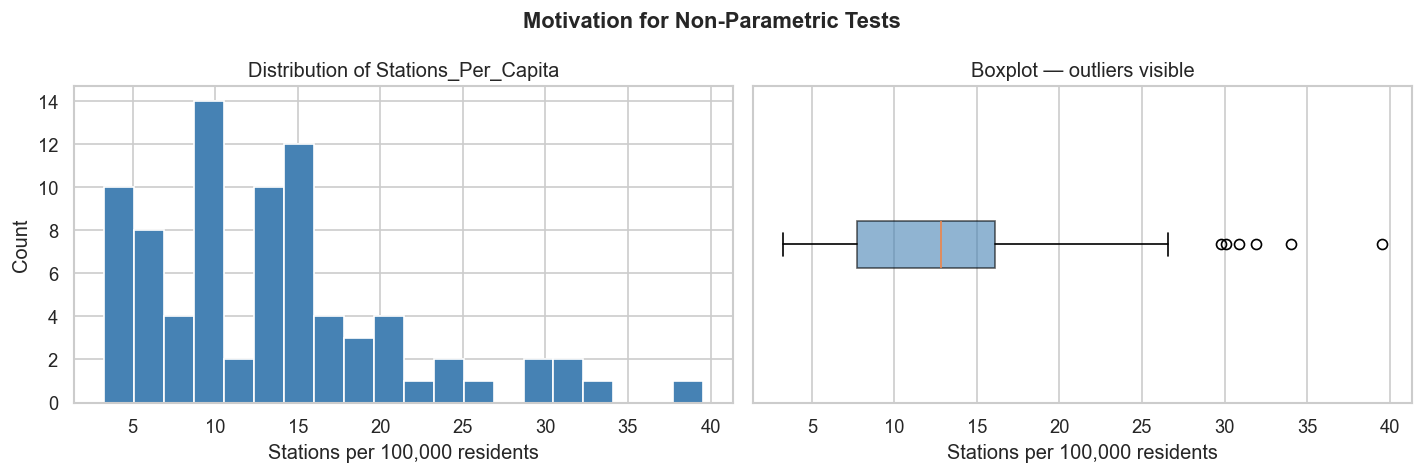

In [3]:
spc = df_merged['Stations_Per_Capita'].dropna()

print('Stations_Per_Capita — descriptive statistics:')
print(spc.describe().round(3))
print(f'\nSkewness : {spc.skew():.2f}  (> 1 → strong right skew)')
print(f'Kurtosis : {spc.kurt():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(spc, bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Stations per 100,000 residents')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Stations_Per_Capita')

axes[1].boxplot(spc, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_xlabel('Stations per 100,000 residents')
axes[1].set_title('Boxplot — outliers visible')
axes[1].set_yticks([])

plt.suptitle('Motivation for Non-Parametric Tests', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'hyp0_distribution.png', bbox_inches='tight')
plt.show()

---
## Test 1 · Mann-Whitney U: Metropolitan vs. Non-Metropolitan

**H₀:** The distribution of `Stations_Per_Capita` is the same for metropolitan and non-metropolitan provinces.  
**H₁:** The two groups differ (two-sided).  
**Method:** `scipy.stats.mannwhitneyu` — does not assume normality.

In [11]:
metro     = df_merged[df_merged['Is_Metropolitan'] == 1]['Stations_Per_Capita'].dropna()
non_metro = df_merged[df_merged['Is_Metropolitan'] == 0]['Stations_Per_Capita'].dropna()

mw_stat, mw_p = mannwhitneyu(metro, non_metro, alternative='two-sided')

print('=== Test 1: Mann-Whitney U ===')
print(f'  Metropolitan   : n={len(metro)}, median={metro.median():.2f}')
print(f'  Non-Metropolitan: n={len(non_metro)}, median={non_metro.median():.2f}')
print(f'  U statistic    : {mw_stat:.1f}')
print(f'  p-value        : {mw_p:.4f}')
if mw_p < ALPHA:
    print(f'  → REJECT H₀ (p={mw_p:.4f} < α={ALPHA})')
    print('  Conclusion: Significant difference in stations per capita between metro and non-metro provinces.')
else:
    print(f'  → FAIL TO REJECT H₀ (p={mw_p:.4f} ≥ α={ALPHA})')
    print('  Conclusion: No significant difference detected.')

=== Test 1: Mann-Whitney U ===
  Metropolitan   : n=30, median=14.78
  Non-Metropolitan: n=51, median=12.12
  U statistic    : 946.0
  p-value        : 0.0775
  → FAIL TO REJECT H₀ (p=0.0775 ≥ α=0.05)
  Conclusion: No significant difference detected.


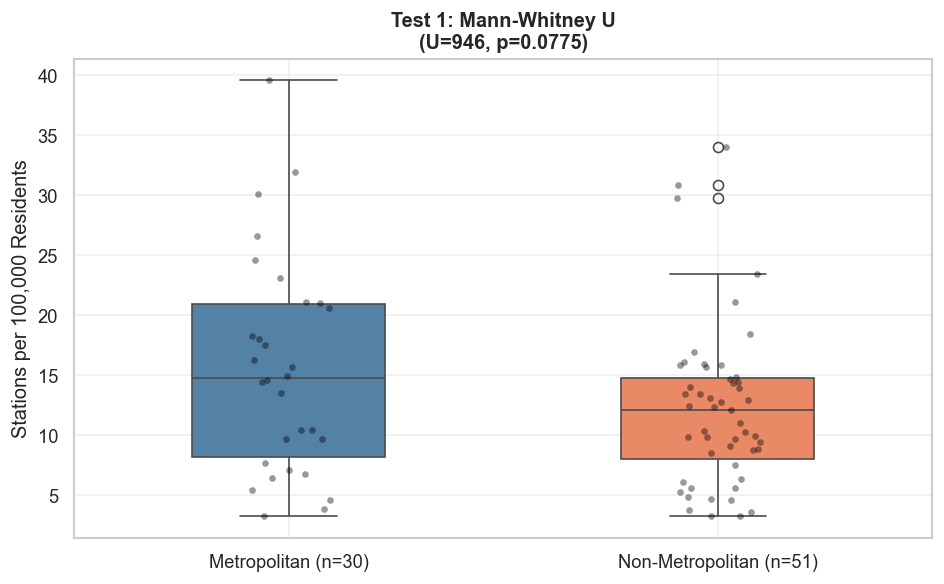

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

df_merged['Metro_Label'] = df_merged['Is_Metropolitan'].map({1: 'Metropolitan (n=30)', 0: 'Non-Metropolitan (n=51)'})

sns.boxplot(
    data=df_merged.dropna(subset=['Stations_Per_Capita']),
    x='Metro_Label', y='Stations_Per_Capita',
    palette={'Metropolitan (n=30)': 'steelblue', 'Non-Metropolitan (n=51)': 'coral'},
    width=0.45, ax=ax
)
sns.stripplot(
    data=df_merged.dropna(subset=['Stations_Per_Capita']),
    x='Metro_Label', y='Stations_Per_Capita',
    color='black', alpha=0.4, size=4, jitter=True, ax=ax
)

ax.set_xlabel('')
ax.set_ylabel('Stations per 100,000 Residents')
ax.set_title(
    f'Test 1: Mann-Whitney U\n(U={mw_stat:.0f}, p={mw_p:.4f})',
    fontweight='bold'
)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / 'hyp1_mann_whitney.png', bbox_inches='tight')
plt.show()

A Mann–Whitney U test was conducted to compare charging station availability per capita between metropolitan and non-metropolitan provinces. 

The results show that metropolitan provinces have a higher median number of stations per capita (14.78) compared to non-metropolitan provinces (12.12). 

However, this difference is not statistically significant at the 5% significance level (U = 946, p = 0.0775). Since the p-value exceeds the threshold (α = 0.05), we fail to reject the null hypothesis, indicating that the observed difference could be due to random variation. Nevertheless, the p-value is relatively close to the significance level, suggesting a weak tendency for metropolitan areas to have better infrastructure, although this effect is not strong enough to be statistically confirmed.

---
## Test 2 · Kruskal-Wallis: Across 7 Geographic Regions

**H₀:** The distribution of `Stations_Per_Capita` is identical across all 7 geographic regions.  
**H₁:** At least one region has a different distribution.  
**Method:** `scipy.stats.kruskal` — non-parametric generalisation of ANOVA.

In [6]:
region_groups = [
    grp['Stations_Per_Capita'].dropna().values
    for _, grp in df_merged.groupby('Region')
]
region_labels = sorted(df_merged['Region'].dropna().unique())

kw_stat, kw_p = kruskal(*region_groups)

print('=== Test 2: Kruskal-Wallis ===')
for label, grp in zip(region_labels, region_groups):
    print(f'  {label:<25}: n={len(grp)}, median={np.median(grp):.2f}')
print(f'\n  H statistic : {kw_stat:.3f}')
print(f'  p-value     : {kw_p:.4f}')
if kw_p < ALPHA:
    print(f'  → REJECT H₀ (p={kw_p:.4f} < α={ALPHA})')
    print('  Conclusion: Significant differences in stations per capita exist across regions.')
else:
    print(f'  → FAIL TO REJECT H₀ (p={kw_p:.4f} ≥ α={ALPHA})')
    print('  Conclusion: No significant regional differences detected.')

=== Test 2: Kruskal-Wallis ===
  Aegean                   : n=8, median=16.46
  Black Sea                : n=16, median=13.26
  Central Anatolia         : n=13, median=14.64
  Eastern Anatolia         : n=14, median=6.24
  Marmara                  : n=12, median=19.53
  Mediterranean            : n=8, median=11.89
  Southeastern Anatolia    : n=9, median=4.69

  H statistic : 46.037
  p-value     : 0.0000
  → REJECT H₀ (p=0.0000 < α=0.05)
  Conclusion: Significant differences in stations per capita exist across regions.


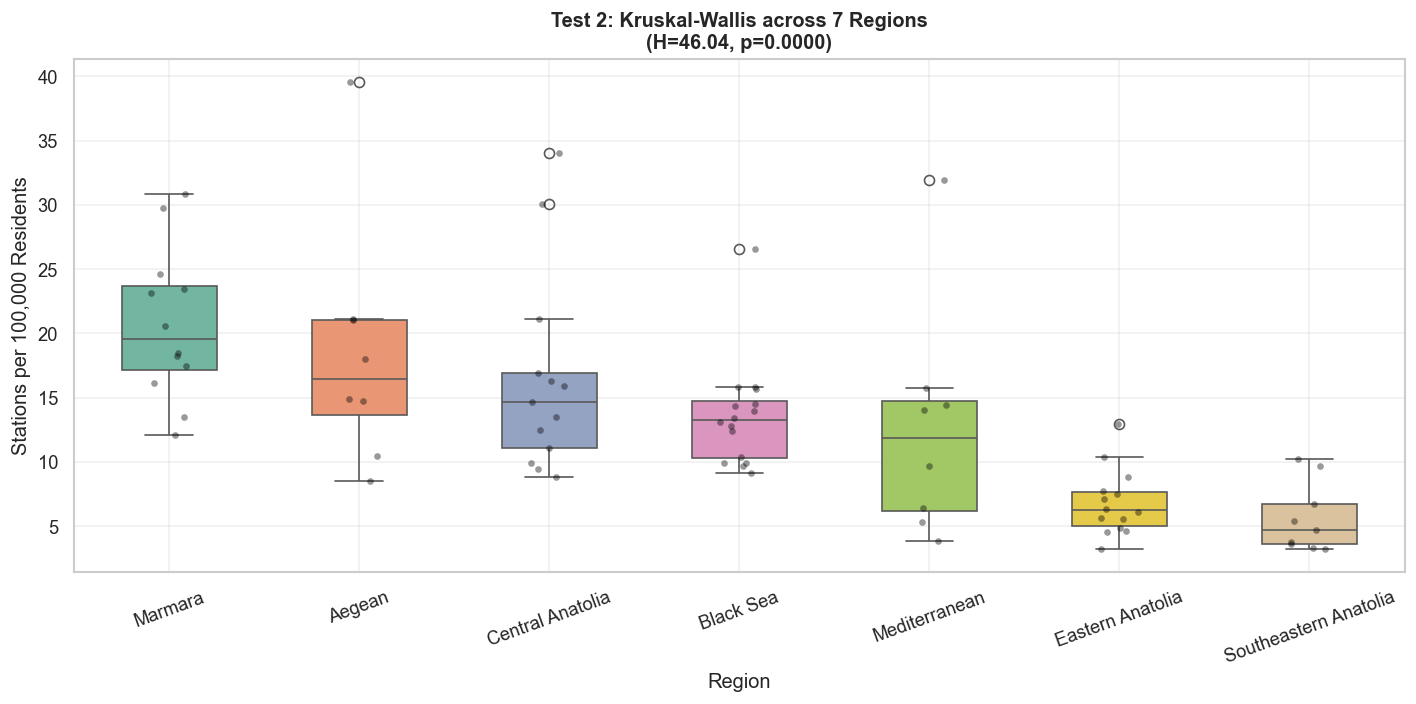

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

region_order = (
    df_merged.groupby('Region')['Stations_Per_Capita']
    .median().sort_values(ascending=False).index.tolist()
)

sns.boxplot(
    data=df_merged.dropna(subset=['Stations_Per_Capita', 'Region']),
    x='Region', y='Stations_Per_Capita',
    order=region_order,
    palette='Set2', width=0.5, ax=ax
)
sns.stripplot(
    data=df_merged.dropna(subset=['Stations_Per_Capita', 'Region']),
    x='Region', y='Stations_Per_Capita',
    order=region_order,
    color='black', alpha=0.4, size=4, jitter=True, ax=ax
)

ax.set_xlabel('Region')
ax.set_ylabel('Stations per 100,000 Residents')
ax.set_title(
    f'Test 2: Kruskal-Wallis across 7 Regions\n(H={kw_stat:.2f}, p={kw_p:.4f})',
    fontweight='bold'
)
ax.tick_params(axis='x', rotation=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / 'hyp2_kruskal_wallis.png', bbox_inches='tight')
plt.show()

A Kruskal–Wallis test was conducted to examine whether charging station availability per capita differs across Turkey’s seven geographic regions. The results indicate a statistically significant difference between regions (H = 46.04, p < 0.001), leading to rejection of the null hypothesis. 

This suggests that at least one region differs substantially from the others in terms of infrastructure availability. Examination of median values reveals a clear regional pattern: western regions such as Marmara and the Aegean exhibit the highest infrastructure levels, while Eastern and Southeastern Anatolia show considerably lower values. This confirms the presence of strong regional disparities in EV charging infrastructure across Turkey.

---
## Test 3 · Chi-Square Goodness of Fit: Observed vs. Population-Expected Distribution

**H₀:** The distribution of charging stations across 81 provinces matches what their population shares would predict.  
**H₁:** The observed distribution significantly deviates from population-proportional expectation.  
**Method:** `scipy.stats.chisquare` with expected values derived from province population proportions.

In [8]:
df_chi = df_merged[['Province', 'Total_Stations', 'Population']].dropna().copy()
df_chi = df_chi[df_chi['Population'] > 0]

total_stations = df_chi['Total_Stations'].sum()
df_chi['Expected'] = (
    df_chi['Population'] / df_chi['Population'].sum() * total_stations
)

chi_stat, chi_p = chisquare(
    f_obs=df_chi['Total_Stations'].values,
    f_exp=df_chi['Expected'].values
)

print('=== Test 3: Chi-Square Goodness of Fit ===')
print(f'  Total observed stations : {total_stations:,}')
print(f'  Provinces in test       : {len(df_chi)}')
print(f'  Chi² statistic          : {chi_stat:.2f}')
print(f'  p-value                 : {chi_p:.4e}')
if chi_p < ALPHA:
    print(f'  → REJECT H₀ (p={chi_p:.2e} < α={ALPHA})')
    print('  Conclusion: Station distribution does NOT follow population proportions.')
    print('  Some provinces are significantly over- or under-served relative to their population.')
else:
    print(f'  → FAIL TO REJECT H₀ (p={chi_p:.2e} ≥ α={ALPHA})')
    print('  Conclusion: Station distribution is consistent with population proportions.')

=== Test 3: Chi-Square Goodness of Fit ===
  Total observed stations : 14,811
  Provinces in test       : 81
  Chi² statistic          : 3788.67
  p-value                 : 0.0000e+00
  → REJECT H₀ (p=0.00e+00 < α=0.05)
  Conclusion: Station distribution does NOT follow population proportions.
  Some provinces are significantly over- or under-served relative to their population.


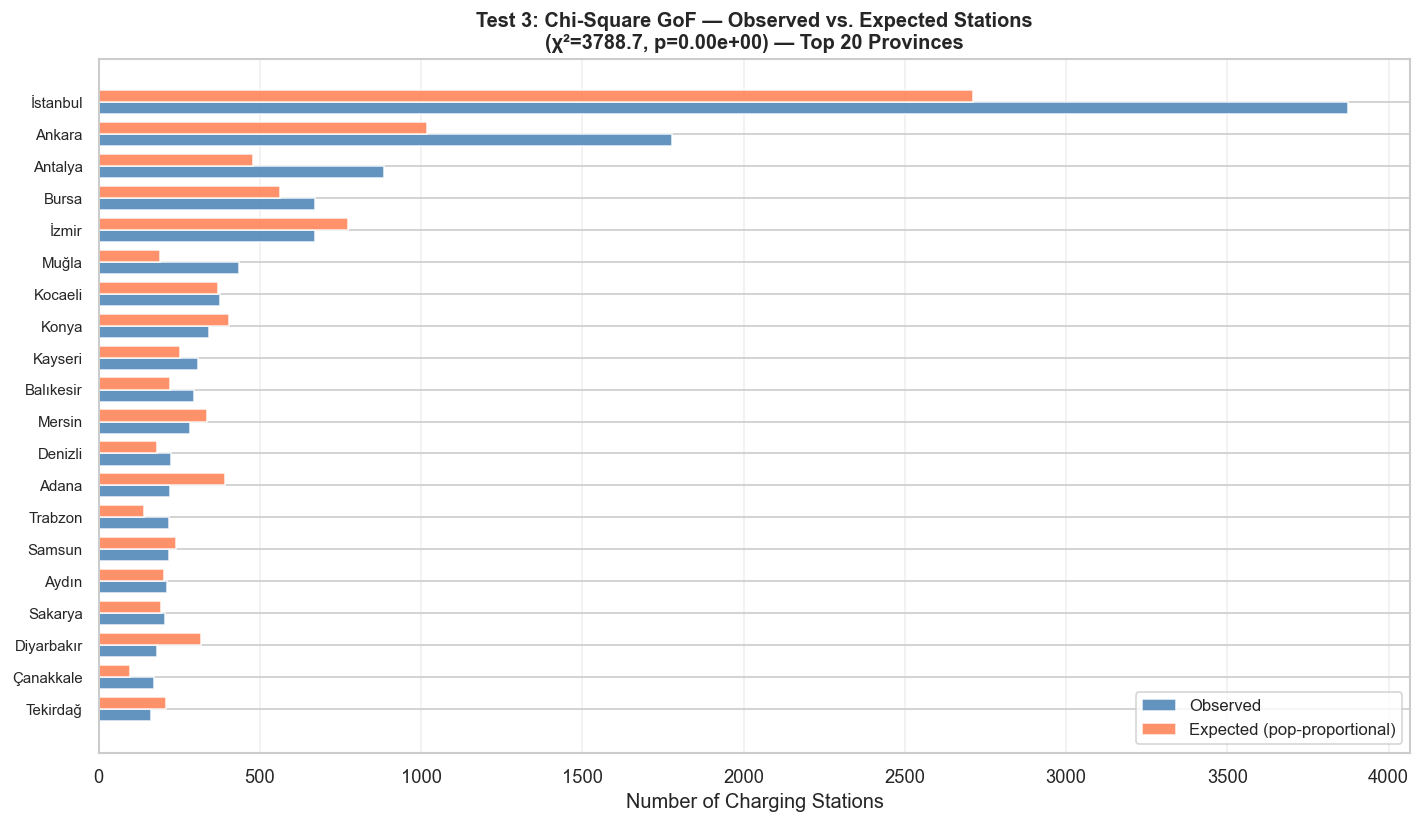

In [9]:
# Top 20 provinces by observed stations for the chart
df_top20 = df_chi.nlargest(20, 'Total_Stations').sort_values('Total_Stations', ascending=True)

x   = np.arange(len(df_top20))
w   = 0.38

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(x - w/2, df_top20['Total_Stations'], w,
        label='Observed', color='steelblue', alpha=0.85)
ax.barh(x + w/2, df_top20['Expected'],       w,
        label='Expected (pop-proportional)', color='coral', alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(df_top20['Province'], fontsize=9)
ax.set_xlabel('Number of Charging Stations')
ax.set_title(
    f'Test 3: Chi-Square GoF — Observed vs. Expected Stations\n'
    f'(χ²={chi_stat:.1f}, p={chi_p:.2e}) — Top 20 Provinces',
    fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(FIGURES / 'hyp3_chi_square.png', bbox_inches='tight')
plt.show()

A Chi-Square Goodness-of-Fit test was conducted to evaluate whether the distribution of EV charging stations across provinces aligns with population proportions. The results reveal a highly significant deviation from the expected distribution (χ² = 3788.67, p < 0.001), leading to rejection of the null hypothesis. This indicates that charging infrastructure is not allocated proportionally to population size. Instead, certain provinces ,particularly major metropolitan areas such as Istanbul and Ankara, are substantially over-served relative to their population, while others receive fewer stations than expected. This suggests that infrastructure deployment is influenced more by economic activity, demand concentration, and urbanization rather than purely by population distribution.

---
## Summary Table

In [10]:
def decision(p):
    return f'Reject H₀' if p < ALPHA else 'Fail to Reject H₀'

summary = pd.DataFrame([
    {
        'Test'       : 'Mann-Whitney U',
        'Comparison' : 'Metro vs. Non-Metro (Stations_Per_Capita)',
        'Statistic'  : f'U = {mw_stat:.1f}',
        'p-value'    : f'{mw_p:.4f}',
        'Decision'   : decision(mw_p)
    },
    {
        'Test'       : 'Kruskal-Wallis',
        'Comparison' : 'Across 7 Geographic Regions (Stations_Per_Capita)',
        'Statistic'  : f'H = {kw_stat:.3f}',
        'p-value'    : f'{kw_p:.4f}',
        'Decision'   : decision(kw_p)
    },
    {
        'Test'       : 'Chi-Square GoF',
        'Comparison' : 'Station distribution vs. population proportions',
        'Statistic'  : f'χ² = {chi_stat:.2f}',
        'p-value'    : f'{chi_p:.2e}',
        'Decision'   : decision(chi_p)
    },
])

print(f'Significance level: α = {ALPHA}\n')
display(summary)

Significance level: α = 0.05



,Test,Comparison,Statistic,p-value,Decision
0,Mann-Whitney U,Metro vs. Non-Metro (Stations_Per_Capita),U = 946.0,0.0775,Fail to Reject H₀
1,Kruskal-Wallis,Across 7 Geographic Regions (Stations_Per_Capita),H = 46.037,0.0000,Reject H₀
2,Chi-Square GoF,Station distribution vs. population proportions,χ² = 3788.67,0.00e+00,Reject H₀
